Implementing TunED as in the paper, checking for the driver variable between % of escape and shelter distance in the escape/homing period
Comparison between real and predicted is done using euclidean distance
Stats are done using bootstrap with sampling with replacement

In [91]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from JR_test_scripts.escape.escape_utils import load, load_homing, compute_dist_shelt, firing_by_bin_median_numba
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods, build_shift_vector
from JR_test_scripts.escape.escape_tuning_funcs import nan_winsorized_mean_2d

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic, norm
from scipy.ndimage import gaussian_filter1d
from scipy.stats.mstats import winsorize
from matplotlib_venn import venn3

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [134]:
"""All the needed functions"""

def tuning_method_TunED(var, escape_matrix, cond, h_start, bins, n_cond, n_neur):
    """
    Computes tuning curves across conditions and neurons, including mean firing rate, 
    variance + (mean^2), and number of samples per bin.

    RETURNS:
        fr_full:    (n_cond, n_neur, bins) - Average firing rate across trials.
    """
    # Initialize output variables
    fr_full = np.zeros((n_cond, n_neur, bins)) # conditions x neurons x n_bins
    c = [len([x for x in h_start if cond[x] == i]) for i in range(n_cond)] # what is the max number of trials across all conditions

    # Step 1: Compute firing per bin per trial
    for i in range(n_cond):  # Loop over conditions
        # Find trial indices for this condition
        cond_start = [x for x in h_start if cond[x] == int(i)]
        cond_start.append(np.sum(cond == int(i)))

        for j, n in enumerate(escape_matrix):  # Loop over neurons
            mat = np.full((max(c),bins), np.nan) # conditions x neurons x trials x bins
            for tr, _ in enumerate(cond_start[:-1]):
                neur = n[cond_start[tr]:cond_start[tr+1]]
                v = var[cond_start[tr]:cond_start[tr+1]]
                
                # Compute firing per bin (without removing empty bins)
                mat[tr,:] = firing_by_bin_median_numba(v.astype(int), neur, bins, remove_empty=False)

            # Step 2: Compute winsorized mean across trials
            all_nan_cols = np.all(np.isnan(mat), axis=0)
            smoothed_firing_rates = np.full(bins, np.nan)

            if np.any(~all_nan_cols):  # If at least one non-NaN column exists
                valid_data = mat[:, ~all_nan_cols]  # Exclude all-NaN columns
                
                # Compute winsorized mean
                smoothed_firing_rates[~all_nan_cols] = nan_winsorized_mean_2d(valid_data, limits=(.15, .15), axis=0)

            # Store results
            fr_full[i, j, :] = smoothed_firing_rates

    return fr_full

def estimate_p_conditional_LF(v1, v2, bin_edges):

    # Compute joint histogram P(v1, v2)
    joint_prob, _, _ = np.histogram2d(v1, v2, bins=[bin_edges, bin_edges], density=True)

    # Compute marginal probability P(v2)
    Pv1 = np.sum(joint_prob, axis=0)
    Pv2 = np.sum(joint_prob, axis=1)

    # Compute conditional probability P(v1 | v2) (avoid division by zero)
    Pv2_v1 = joint_prob / (np.ones(len(Pv2)).reshape(-1, 1) * (Pv1 + 1e-8))
    Pv1_v2 = joint_prob.T / (np.ones(len(Pv1)).reshape(-1, 1) * (Pv2 + 1e-8))  # P(v1|v2)

    return Pv2_v1, Pv1_v2

def compute_expected_tuning_LF(mu_v1, p_v1_given_v2):
    """INPUTS: mu_v1: mean tuning curve for v1
               p_v1_given_v2: conditional probability of v1 given v2"""
    Nbins_x = p_v1_given_v2.shape[1]
    mu_NH_v2 = np.sum((mu_v1[:, None] @ np.ones((1, Nbins_x))) * p_v1_given_v2, axis=0) # Turn ty_y into a column vector and multiply by Py_x
    return mu_NH_v2

def compare_curves(mu_v1, mu_v2, mu_NH_v1, mu_NH_v2):
    """Compute the difference in euclidean distance between real and expected tuning curves"""
    
    dv1 = np.sqrt(np.sum((mu_v1 - mu_NH_v1)**2))
    dv2 = np.sqrt(np.sum((mu_v2 - mu_NH_v2)**2))

    # Store difference
    dv1_minus_dv2 = dv1 - dv2

    return dv1_minus_dv2

In [126]:
"""Load in and extract all necessary data"""
# from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar
# exp = JAL6_flip4_21mar

# %autoreload 2
# # 1. load in distance to shelter in escape/homing tuning curve
# comp = 'bird_dist_shelter'
# nickname = exp.nick_name + '_' + exp.experiment_date
# exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
# dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/median/" + nickname)
# saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
# data = np.load(saving_file)

# # pull out the params
# data_files = data.files
# if 'params_real' in data_files:
#     exp_params_real = data['params_real']
#     exp_params_shifts = data['params_shifts']
# else:
#     exp_params_real = data["arr_12"]
#     exp_params_shifts = data["arr_1"]

# # create vector of which cells are sig to distance in exploration
# # find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
# exp_sig_cells = exp_params_real[:,:,0] > np.nanpercentile(exp_params_shifts[:,:,:,0], 95, axis = 0)

# # 2. load in %escape in homing/escape tuning curve
# comp = 'escape'
# exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
# dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/median/" + nickname)
# saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
# data = np.load(saving_file)

# data_files = data.files
# params_real = data['params_real']
# params_shifts = data['params_shifts']

# # create vector of which cells are sig to fraction of escape
# # find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
# sig_cells = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)

# # 3. load in neural data
# session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
# ons, offs, homie = load_homing(session, len(behave))
# fcm = gaussian_filter1d(frame_by_cluster_matrix, 2, axis = 0)

# # 4. extract escape matrix with respect to 'escape'
# comp = 'escape'
# frac_escape, escape_matrix, cond, h_start = extract_homing_and_escape_periods(session, 
#                                                                                 fcm, 
#                                                                                 behave, 
#                                                                                 y_pos, x_pos, 
#                                                                                 bar, 
#                                                                                 barflip, 
#                                                                                 comp, 
#                                                                                 ons, offs, 
#                                                                                 no_stationary = False, 
#                                                                                 return_escape = False,
#                                                                                 zscore = False)

# # initialize vars
# bins_escape = int(np.amax(frac_escape)+1)
# n_neur = frame_by_cluster_matrix.shape[1]
# n_cond = len(np.unique(cond))

# # 5. extract neural data with respect to 'distance to shelter'
# comp = 'bird_dist_shelter'
# full_bird_dist_shelt = compute_dist_shelt(x_pos, y_pos, cond=np.zeros_like(x_pos), session=session)
# bin_size = np.amax(full_bird_dist_shelt)/(bins_escape)
# shelt_dist, _, _, _ = extract_homing_and_escape_periods(session, 
#                                                         fcm, 
#                                                         behave, 
#                                                         y_pos, x_pos, 
#                                                         bar, 
#                                                         barflip, 
#                                                         comp, 
#                                                         ons, offs, 
#                                                         no_stationary = False, 
#                                                         return_escape = False,
#                                                         zscore = False,
#                                                         bin_size = bin_size)

# # initialize vars
# bins_dist = int(np.amax(shelt_dist)+1)

# 6. recompute tuning curve for distance to shelter with the same number of bins as escape
# Nbins = bins_escape
# fr_esc = tuning_method_TunED(frac_escape, escape_matrix, cond, h_start, Nbins, n_cond, n_neur)
# fr_dist = tuning_method_TunED(shelt_dist, escape_matrix, cond, h_start, Nbins, n_cond, n_neur)

# perform tuned on cells of interest
dv1_minus_dv2 = np.full_like(sig_cells, np.nan, dtype = float)
mu_NH_v2 = np.full((n_neur,n_cond, Nbins), np.nan)
mu_NH_v1 = np.full((n_neur,n_cond, Nbins), np.nan)
#TODO: save all these vairables for plotting!

for c in [0,1,2]: # which condition do we want to look at

    for idx in range(n_neur):
        # Step 1: Real Observed Tuning Curves and their variance
        mu_v1 = fr_esc[c, idx,:]
        mu_v2 = fr_dist[c, idx,:]

        # Step 3: Estimate P(v1 | v2) and P(v2 | v1)
        v1 = frac_escape[cond == c]
        v2 = shelt_dist[cond == c]
        bin_edges = np.arange(Nbins + 1)

        Pv2_v1, Pv1_v2 = estimate_p_conditional_LF(v1, v2, bin_edges)

        # Step 4: Compute Expected Tuning Curve Under NH

        mu_NH_v2[idx,c,:] = compute_expected_tuning_LF(mu_v1, Pv1_v2) # tuning to v2 given that driver is v1
        mu_NH_v1[idx,c,:] = compute_expected_tuning_LF(mu_v2, Pv2_v1) # tuning to v1 given that driver is v2

        # Step 5: Compare Actual vs Expected Tuning for significance
        dv1_minus_dv2[idx, c] = compare_curves(mu_v1, mu_v2, mu_NH_v1[idx,c,:], mu_NH_v2[idx,c,:])

In [120]:
"""This is where we do the tuned boostrapping!"""

# create resampling vectors with replacement, but wuch that we only resample within the same condition
num_samples = 100
for c in range(3):
    frames_vec = np.arange(np.sum(cond == c))
    resampled_condition = np.random.choice(frames_vec, (num_samples, len(frames_vec)), replace=True)
    if c == 0:
        resampled_vectors = resampled_condition
    else:
        resampled_vectors = np.hstack((resampled_vectors, resampled_condition + resampled_vectors.shape[1]))

dv1_minus_dv2_dist = np.full((num_samples,n_cond,n_neur), np.nan)
bs_esc = np.full((resampled_vectors.shape[0],n_cond,n_neur,Nbins),np.nan)
bs_dist = np.full((resampled_vectors.shape[0],n_cond,n_neur,Nbins),np.nan)
mu_NH_v2_bs = np.full((resampled_vectors.shape[0],n_neur,n_cond, Nbins), np.nan)
mu_NH_v1_bs = np.full((resampled_vectors.shape[0],n_neur,n_cond, Nbins), np.nan)

# iterate over resampling vectors
for i, v in enumerate(resampled_vectors):

    # resample behavioral variables and neural activity
    em = escape_matrix[:,v]
    esc = frac_escape[v]
    dist = shelt_dist[v]

    # step1. recompute tuning curve for distance to shelter with the same number of bins as escape
    bs_esc[i,:,:,:] = tuning_method_TunED(esc, em, cond, h_start, Nbins, n_cond, n_neur)
    bs_dist[i,:,:,:] = tuning_method_TunED(dist, em, cond, h_start, Nbins, n_cond, n_neur)

    for c in [0,1,2]: # which condition do we want to look at

        for idx in range(n_neur):
            # Step 2: Real Observed Tuning Curves
            mu_v1 = bs_esc[i, c, idx,:]
            mu_v2 = bs_dist[i, c, idx,:]

            # Step 3: Estimate P(v1 | v2) and P(v2 | v1)
            v1 = esc[cond == c]
            v2 = dist[cond == c]
            bin_edges = np.arange(Nbins + 1)

            Pv2_v1, Pv1_v2 = estimate_p_conditional_LF(v1, v2, bin_edges)

            # Step 4: Compute Expected Tuning Curve Under NH

            mu_NH_v2_bs[i,idx,c,:] = compute_expected_tuning_LF(mu_v1, Pv1_v2) # tuning to v2 given that driver is v1
            mu_NH_v1_bs[i,idx,c,:] = compute_expected_tuning_LF(mu_v2, Pv2_v1) # tuning to v1 given that driver is v2

            # Step 5: Compare Actual vs Expected Tuning for significance
            dv1_minus_dv2_dist[i,c,idx] = compare_curves(mu_v1, mu_v2, mu_NH_v1_bs[i,idx,c,:], mu_NH_v2_bs[i,idx,c,:])

Text(0.5, 0, '%escape')

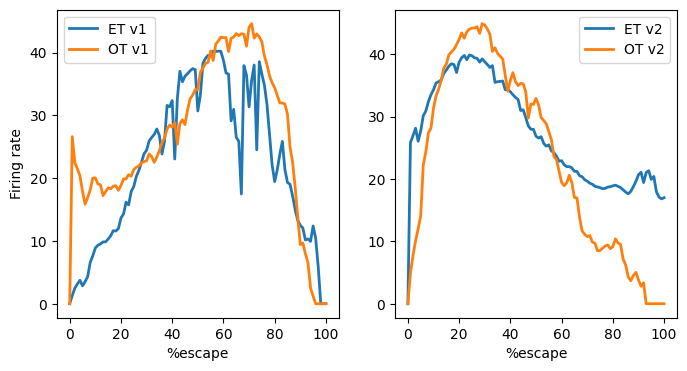

In [133]:
c = 0 # which condition do we want to look at
goodones = np.where(np.logical_and(exp_sig_cells[:,c], sig_cells[:,c]))[0]
idx = 11

fig, axs = plt.subplots(1,2,figsize = (8,4))
axs[0].plot(mu_NH_v1_bs[:,goodones[idx],c,:].T,'C0',linewidth = .5, alpha = .5)
axs[0].plot(mu_NH_v1[goodones[idx],c,:],'C0',linewidth = 2, label = 'ET v1')
axs[0].plot(bs_esc[:, c, goodones[idx],:].T,'C1',linewidth = .5, alpha = .5) # bootstrapped mu_v1
axs[0].plot(fr_esc[c, goodones[idx],:],'C1',linewidth = 2, label = 'OT v1') # mu_v1
axs[0].legend()
axs[0].set_ylabel('Firing rate')
axs[0].set_xlabel(r'% escape')

axs[1].plot(mu_NH_v2_bs[:,goodones[idx],c,:].T,'C0',linewidth = .5, alpha = .5)
axs[1].plot(mu_NH_v2[goodones[idx],c,:],'C0',linewidth = 2, label = 'ET v2')
axs[1].plot(bs_dist[:, c, goodones[idx],:].T,'C1',linewidth = .5, alpha = .5)
axs[1].plot(fr_dist[c, goodones[idx],:],'C1',linewidth = 2, label = 'OT v2') # mu_v2
axs[1].legend()
axs[1].set_xlabel(r'% escape')

Text(0, 0.5, 'number of significant cells')

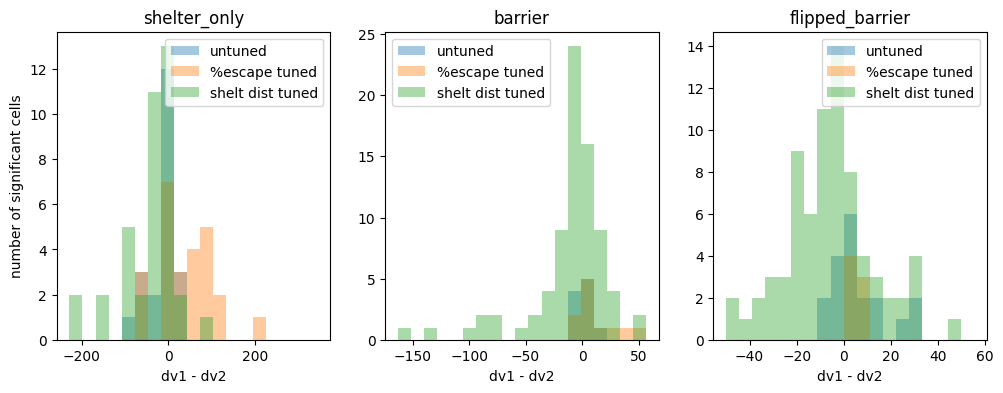

In [ ]:

"""Plot the distribution of difference between the distance between v1 and nh_given_v2 and between v2 and nh_given_v1
Show only the cells that are significantly tuned to %escape and shelter distance
Divide cells by whether tuned analysis classifies them as tuned to v1, v2 or undecided"""

c_names = ['shelter_only', 'barrier', 'flipped_barrier']
fig, axs = plt.subplots(1,3,figsize = (12,4))
for c in range(3):
    goodones = np.where(np.logical_and(exp_sig_cells[:,c], sig_cells[:,c]))[0]
    diff_this_c = dv1_minus_dv2[goodones,c]
    lower_percentile, upper_percentile = np.percentile(dv1_minus_dv2_dist[:,c,goodones], [2.5, 97.5], axis = 0)
    v1_sig = (lower_percentile > 0) & (upper_percentile > 0)
    v2_sig = (lower_percentile < 0) & (upper_percentile < 0)
    untuned = ~v1_sig & ~v2_sig
    axs[c].hist(diff_this_c[untuned], bins = np.arange(np.amin(diff_this_c), np.amax(diff_this_c), (np.amax(diff_this_c)-np.amin(diff_this_c))/20), label = r'untuned', alpha = .4)
    axs[c].hist(diff_this_c[v1_sig], bins = np.arange(np.amin(diff_this_c), np.amax(diff_this_c), (np.amax(diff_this_c)-np.amin(diff_this_c))/20), label = r'%escape tuned', alpha = .4)
    axs[c].hist(diff_this_c[v2_sig], bins = np.arange(np.amin(diff_this_c), np.amax(diff_this_c), (np.amax(diff_this_c)-np.amin(diff_this_c))/20), label = r'shelt dist tuned', alpha = .4)
    axs[c].legend()
    axs[c].set_xlabel('dv1 - dv2')
    axs[c].set_title(c_names[c])
axs[0].set_ylabel('number of significant cells')

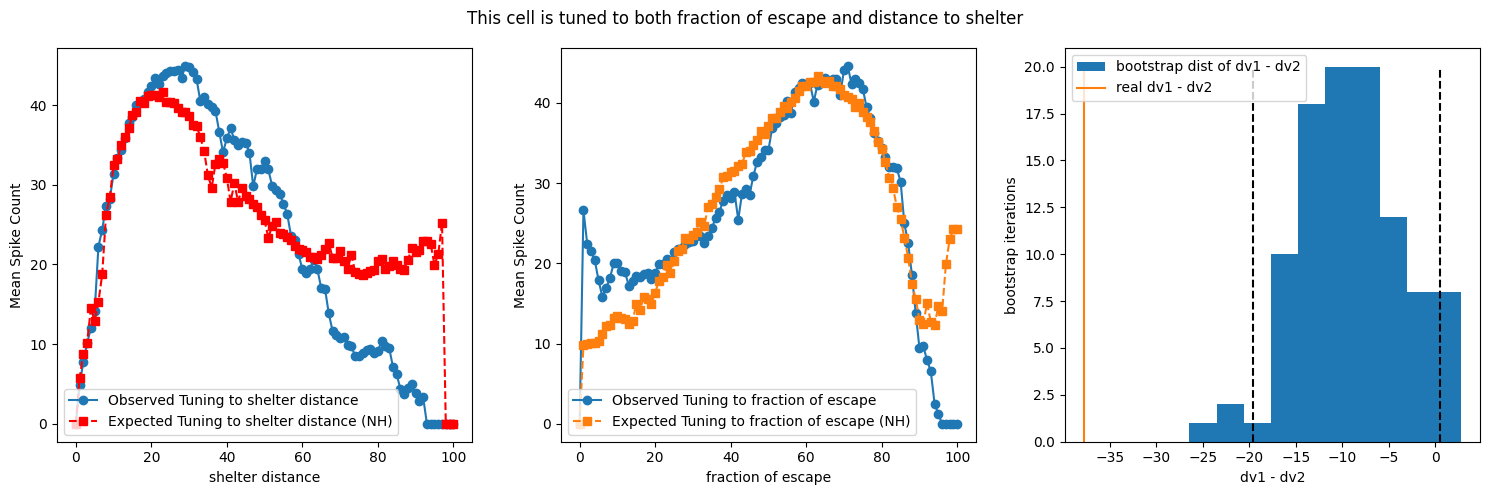

In [ ]:
"""Plot LF method for tunED
If a cell is tuned to v1 (escape) then 
    - shifting v1 will cause a significant change in the number of different bins between the v1 observed tuning curve and the expected tuning curve based on v2
    - shifting v2 will not cause a significant change in the number of different bins between the v2 observed tuning curve and the expected tuning curve based on v1
Therefore if we shift v1, is_v1_sig will tell us whether to reject the v2 null hypothesis"""

# choose a cell to test
c = 0 # which condition do we want to look at
goodones = np.where(np.logical_and(exp_sig_cells[:,c], sig_cells[:,c]))[0]
idx = 11

# Step 1: Real Observed Tuning Curves and their variance
mu_v1 = fr_esc[c, goodones[idx],:]
mu_v2 = fr_dist[c, goodones[idx],:]

fig, axs = plt.subplots(1,3,figsize=(15,5))

# Plot Results v1
axs[0].plot(bin_edges[:-1], mu_v2, label="Observed Tuning to shelter distance", marker='o')
axs[0].plot(bin_edges[:-1], mu_NH_v2[goodones[idx],c,:], label="Expected Tuning to shelter distance (NH)", linestyle='--', marker='s', color='r')
axs[0].set_xlabel("shelter distance")
axs[0].set_ylabel("Mean Spike Count")
axs[0].legend()

# Plot Results v2
axs[1].plot(bin_edges[:-1], mu_v1, label="Observed Tuning to fraction of escape", marker='o')
axs[1].plot(bin_edges[:-1], mu_NH_v1[goodones[idx],c,:], label="Expected Tuning to fraction of escape (NH)", linestyle='--', marker='s')
axs[1].set_xlabel("fraction of escape")
axs[1].set_ylabel("Mean Spike Count")
axs[1].legend()

reject_v1_nh, reject_v2_nh = False, False
lower_percentile, upper_percentile = np.percentile(dv1_minus_dv2_dist[:,c,goodones[idx]], [2.5, 97.5])
if lower_percentile < 0 and upper_percentile < 0:
    reject_v1_nh = True # this mean that you can reject the null hypothesis that v1 is the driver, so the cell is tuned to v2
if lower_percentile > 0 and upper_percentile > 0:    
    reject_v2_nh = True # this mean that you can reject the null hypothesis that v2 is the driver, so the cell is tuned to v1

if reject_v2_nh:
    fig.suptitle("This cell is tuned to fraction of escape, not distance to shelter")
if reject_v1_nh:
    fig.suptitle("This cell is tuned to distance to shelter, not fraction of escape")
if not reject_v1_nh and not reject_v2_nh:
    fig.suptitle("This cell is tuned to both fraction of escape and distance to shelter")

axs[2].hist(dv1_minus_dv2_dist[:,c,goodones[idx]], label = 'bootstrap dist of dv1 - dv2')
axs[2].plot([dv1_minus_dv2[goodones[idx],c],dv1_minus_dv2[goodones[idx],c]],[0,20], label = 'real dv1 - dv2')
axs[2].plot([lower_percentile,lower_percentile],[0,20],'--k')
axs[2].plot([upper_percentile,upper_percentile],[0,20],'--k')
axs[2].set_xlabel('dv1 - dv2')
axs[2].set_ylabel('bootstrap iterations')
axs[2].legend()

plt.tight_layout()
plt.show()

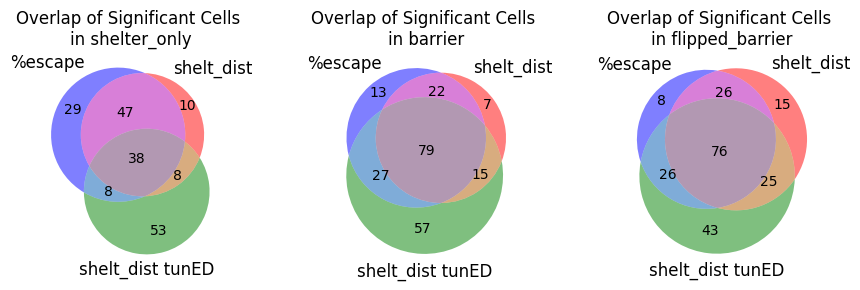

In [99]:
"""Venn diagram"""

fig, axs = plt.subplots(1,3,figsize=(9, 3))
for c in range(3):
    diff_this_c = dv1_minus_dv2[:,c]
    dist_this_c = dv1_minus_dv2_dist[:,c,:]
    lower_percentile, upper_percentile = np.percentile(dist_this_c, [2.5, 97.5], axis = 0)
    v1_sig = (lower_percentile > 0) & (upper_percentile > 0)
    v2_sig = (lower_percentile < 0) & (upper_percentile < 0)
    untuned = ~v1_sig & ~v2_sig
    third = v2_sig
    # Compute Set Sizes
    A = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == False) & (third == False))  # V1 only
    B = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == True) & (third == False))  # V2 only
    C = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == False) & (third == True))  # V1 regressed
    AB = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == True) & (third == False))  # Both V1 and V2
    AC = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == False) & (third == True))  # Both V1 and V1 regressed
    BC = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == True) & (third == True))  # Both V2 and V1 regressed
    ABC = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == True) & (third == True))  # All three

    # Create Venn Diagram
    venn3(subsets=(A, B, AB, C, AC, BC, ABC), 
        set_labels=(r'%escape', 'shelt_dist', r'shelt_dist tunED'), 
        set_colors=('blue', 'red', 'green'),
        alpha=0.5,
        ax=axs[c])
    axs[c].set_title('Overlap of Significant Cells \nin ' + c_names[c])
plt.tight_layout()

In [ ]:
"""Plot the conditional probabilities of the behaviors"""
fig, axs = plt.subplots(1,2,figsize=(10,5))

cb = axs[0].imshow(p_v1_given_v2, cmap="Blues", aspect="auto")
axs[0].set_xlabel("v1 values")
axs[0].set_ylabel("v2 values")
fig.colorbar(cb, ax=axs[0], location='right', anchor=(0, 0.3), shrink=0.7)
axs[0].set_title("Estimated P(v1 | v2) using Discrete Bins")

cb = axs[1].imshow(p_v2_given_v1, cmap="Blues", aspect="auto")
axs[1].set_xlabel("v1 values")
axs[1].set_ylabel("v2 values")
fig.colorbar(cb, ax=axs[1], location='right', anchor=(0, 0.3), shrink=0.7)
axs[1].set_title("Estimated P(v1 | v2) using Discrete Bins")